# EKF Validation Notebook

Quick-turnaround validation against ground truth flight data.

**Workflow:**
1. Load ground truth CSV (already done below)
2. Generate synthetic noisy sensor measurements from it
3. Implement your EKF in the `EKF` class (Section 3)
4. Run the replay loop
5. Look at diagnostic plots

**Scope for this notebook:** Stage 1 — 1D vertical filter. State = `[altitude, vertical_velocity]`. Inputs: vertical accelerometer. Measurement: barometric altitude. Once this works, you can extend.

## 1. Imports and data loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(42)  # reproducible noise

# --- Load ground truth ---
SIMULATION_NAME: str = "01_asteria"
DATA_PATH = "../../simulated_data/" + SIMULATION_NAME + "/ground_truth.csv"
gt = pd.read_csv(DATA_PATH)

print(f'Loaded {len(gt)} samples')
print(f'Duration: {gt["time"].iloc[-1]:.1f} s')
print(f'Sample rate: {1/gt["time"].diff().median():.0f} Hz')
print(f'Apogee: {gt["z"].max():.1f} m at t={gt.loc[gt["z"].idxmax(), "time"]:.2f}s')
print(f'Launch altitude: {gt["z"].iloc[0]:.1f} m')
gt.head()

Loaded 183770 samples
Duration: 459.4 s
Sample rate: 400 Hz
Apogee: 6693.5 m at t=37.92s
Launch altitude: 113.0 m


,time,x,y,z,vx,vy,vz,ax,ay,az,qw,qx,qy,qz,wx,wy,wz,pressure
0,0.0000,0.000000,0.000000,113.000000,0.000000,0.000000,0.000000,1.863401,-2.564751,36.235630,-0.308723,0.013479,-0.041485,0.950151,0.000000e+00,0.000000e+00,0.000000e+00,100000.0
1,0.0025,0.000012,-0.000016,113.000226,0.004659,-0.006412,0.090597,1.863571,-2.564985,36.238939,-0.308723,0.013479,-0.041485,0.950151,-8.165126e-202,8.165126e-202,6.532101e-201,100000.0
2,0.0050,0.000035,-0.000048,113.000680,0.009318,-0.012826,0.181203,1.863741,-2.565219,36.242245,-0.308723,0.013479,-0.041485,0.950151,3.266050e-201,-4.082563e-201,-3.919261e-200,100000.0
3,0.0075,0.000064,-0.000088,113.001246,0.013978,-0.019239,0.271813,1.863911,-2.565453,36.245550,-0.308723,0.013479,-0.041485,0.950151,-1.306420e-200,3.266050e-201,-5.225681e-200,100000.0
4,0.0100,0.000105,-0.000144,113.002039,0.018638,-0.025653,0.362431,1.864081,-2.565687,36.248851,-0.308723,0.013479,-0.041485,0.950151,-5.225681e-200,0.000000e+00,0.000000e+00,100000.0


## 2. Synthetic sensor generation

Since the noise/rate simulation isn't ready yet, we fake it minimally here:
- **Accelerometer (body-frame z, but we'll use world-frame vertical for Stage 1 simplicity):** ground truth `az` + gravity + Gaussian noise + constant bias
- **Barometer:** altitude converted to pressure-equivalent altitude + Gaussian noise + slow bias drift

**Assumption for Stage 1:** rocket is approximately vertical, so body-z accel ≈ world-z accel. This is wrong in detail but fine for validating filter mechanics. Fix this in Stage 3+.

Tweak the noise parameters below to stress-test your filter.

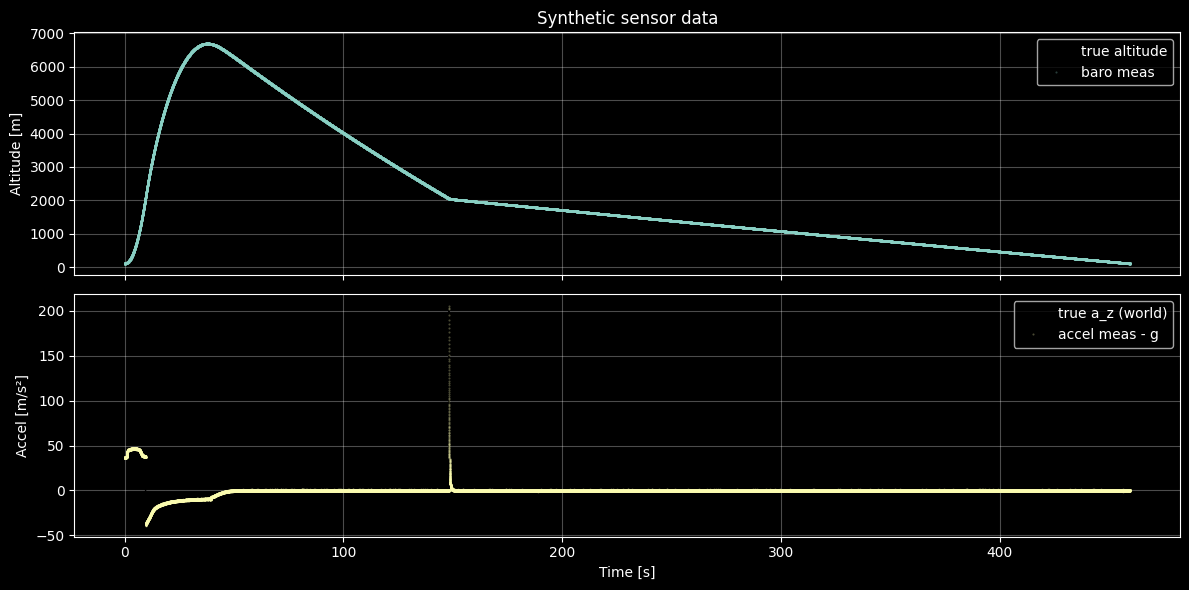

In [4]:
# --- Sensor noise parameters (tune to match your real sensors) ---
ACCEL_NOISE_STD = 0.3        # m/s^2, rough consumer-MEMS value
ACCEL_BIAS = 0.15            # m/s^2, constant offset to test bias handling

BARO_NOISE_STD = 1.5         # m altitude-equivalent, reasonable for BMP388 etc.
BARO_BIAS_DRIFT = 0.0        # m/s drift, set non-zero to stress filter

# Set these to 0 for noise-free sanity check
# ACCEL_NOISE_STD = 0; ACCEL_BIAS = 0; BARO_NOISE_STD = 0

GRAVITY = 9.81  # m/s^2

t = gt['time'].values
N = len(t)

# True vertical accel in world frame (upward positive)
# Ground truth `az` is already world-frame here (z is up)
true_az_world = gt['az'].values

# Accelerometer measures specific force: a_world + gravity (points down -> +g on sensor at rest)
# Convention: at rest, sensor reads +9.81 on vertical axis
accel_meas = true_az_world + GRAVITY + ACCEL_BIAS + np.random.randn(N) * ACCEL_NOISE_STD

# Barometer: convert true altitude to noisy altitude measurement
# (skipping pressure->altitude conversion; your real pipeline will do this)
baro_bias = BARO_BIAS_DRIFT * t
baro_alt_meas = gt['z'].values + baro_bias + np.random.randn(N) * BARO_NOISE_STD

# Quick sanity plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t, gt['z'], 'k-', lw=1, label='true altitude')
axes[0].plot(t, baro_alt_meas, 'C0.', ms=1, alpha=0.3, label='baro meas')
axes[0].set_ylabel('Altitude [m]'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Synthetic sensor data')

axes[1].plot(t, true_az_world, 'k-', lw=1, label='true a_z (world)')
axes[1].plot(t, accel_meas - GRAVITY, 'C1.', ms=1, alpha=0.3, label='accel meas - g')
axes[1].set_ylabel('Accel [m/s²]'); axes[1].set_xlabel('Time [s]')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. EKF implementation — Stage 1

**State:** `x = [altitude, vertical_velocity]`

**Process model** (accel-driven kinematics, input `u` = vertical accel with gravity removed):
```
altitude_{k+1} = altitude_k + velocity_k*dt + 0.5*u*dt²
velocity_{k+1} = velocity_k + u*dt
```

Jacobian `F = [[1, dt], [0, 1]]`

**Measurement model** (barometer):
```
z = altitude + noise    →    H = [1, 0]
```

A working reference implementation is below — modify freely tomorrow. Things to try:
- Add `accel_bias` as a third state (observable because baro corrects it indirectly)
- Swap the covariance update for Joseph form: `P = (I-KH) P (I-KH)' + K R K'`
- Add innovation gating (skip update if `y² / S > threshold`)
- Make `Q` time-varying (higher during boost, lower during coast)


In [5]:
class EKF:
    """Stage 1 EKF: altitude + vertical velocity.

    Technically linear (constant F, H), so this is really a KF — but structured
    as an EKF so you can drop in nonlinear f() and h() tomorrow without reshuffling.
    """

    def __init__(self, x0, P0, Q, R_baro):
        self.x = np.asarray(x0, dtype=float).copy()   # state [altitude, velocity]
        self.P = np.asarray(P0, dtype=float).copy()   # 2x2 covariance
        self.Q = np.asarray(Q, dtype=float)           # 2x2 process noise (per-second)
        self.R_baro = float(R_baro)                   # baro variance [m^2]
        self.n = len(self.x)
        self.I = np.eye(self.n)

    # --- Process model ---
    def f(self, x, u, dt):
        """Propagate state one step. u is vertical accel (gravity removed)."""
        alt, vel = x
        return np.array([
            alt + vel * dt + 0.5 * u * dt**2,
            vel + u * dt,
        ])

    def F_jac(self, dt):
        """Jacobian df/dx. Constant here, but returned per-step for clarity."""
        return np.array([
            [1.0, dt],
            [0.0, 1.0],
        ])

    def predict(self, u, dt):
        F = self.F_jac(dt)
        self.x = self.f(self.x, u, dt)
        # Scale Q by dt so tuning stays invariant to timestep changes
        self.P = F @ self.P @ F.T + self.Q * dt

    # --- Measurement model: barometer ---
    def h_baro(self, x):
        return np.array([x[0]])               # measures altitude

    def H_baro(self):
        return np.array([[1.0, 0.0]])         # Jacobian dh/dx

    def update_baro(self, z_baro):
        H = self.H_baro()
        y = np.array([z_baro]) - self.h_baro(self.x)        # innovation (1,)
        S = H @ self.P @ H.T + self.R_baro                  # innovation cov (1,1)
        K = self.P @ H.T / S[0, 0]                          # Kalman gain (2,1)
        self.x = self.x + (K[:, 0] * y[0])
        # Joseph form — numerically stable; standard form would be (I - K@H) @ P
        IKH = self.I - K @ H
        self.P = IKH @ self.P @ IKH.T + (K * self.R_baro) @ K.T
        return float(y[0]), float(S[0, 0])


# --- Filter tuning ---
# Initial state: on the pad, altitude known from GPS/survey, velocity = 0
x0 = np.array([gt['z'].iloc[0], 0.0])
P0 = np.diag([1.0**2, 0.1**2])     # ±1 m alt, ±0.1 m/s vel at init

# Process noise: represents unmodeled acceleration noise + accel sensor noise
# Rule of thumb: Q_vel ≈ (accel_noise_std)^2, Q_pos small (comes from integrating vel)
Q = np.diag([
    0.01,                          # altitude process noise variance [m^2/s]
    ACCEL_NOISE_STD**2 + 0.5,      # velocity process noise — accel noise + margin
])

# Measurement noise: match actual baro
R_baro = BARO_NOISE_STD**2 if BARO_NOISE_STD > 0 else 1.0

print(f'EKF configured:')
print(f'  x0 = {x0}')
print(f'  P0 diag = {np.diag(P0)}')
print(f'  Q diag  = {np.diag(Q)}')
print(f'  R_baro  = {R_baro:.3f}')

EKF configured:
  x0 = [113.   0.]
  P0 diag = [1.   0.01]
  Q diag  = [0.01 0.59]
  R_baro  = 2.250


## 4. Replay loop

Runs the filter through the whole flight, logs everything needed for diagnostics.

In [6]:
def run_filter(ekf, t, accel_meas, baro_meas, baro_every=1):
    """Replay. `baro_every=N` applies baro update every Nth step (simulate slower rate)."""
    N = len(t)
    log = {
        'x': np.zeros((N, ekf.n)),
        'P': np.zeros((N, ekf.n, ekf.n)),
        'innov': np.full(N, np.nan),
        'innov_cov': np.full(N, np.nan),
        'nis': np.full(N, np.nan),
    }

    for k in range(N):
        if k > 0:
            dt = t[k] - t[k-1]
            u = accel_meas[k-1] - GRAVITY   # input: accel with gravity removed
            ekf.predict(u, dt)

        # Baro update
        if k % baro_every == 0:
            y, S = ekf.update_baro(baro_meas[k])
            y_scalar = float(np.atleast_1d(y)[0])
            S_scalar = float(np.atleast_2d(S)[0, 0]) if np.ndim(S) else float(S)
            log['innov'][k] = y_scalar
            log['innov_cov'][k] = S_scalar
            log['nis'][k] = y_scalar**2 / S_scalar

        log['x'][k] = ekf.x
        log['P'][k] = ekf.P

    return log


# --- Run it ---
ekf = EKF(x0, P0, Q, R_baro)
log = run_filter(ekf, t, accel_meas, baro_alt_meas, baro_every=1)
print('Filter ran to completion.')

Filter ran to completion.


## 5. Diagnostic plots

Run top-to-bottom. Each plot is self-contained so you can jump to the ones you care about.

### 5.1 Estimates vs ground truth (the headline plot)

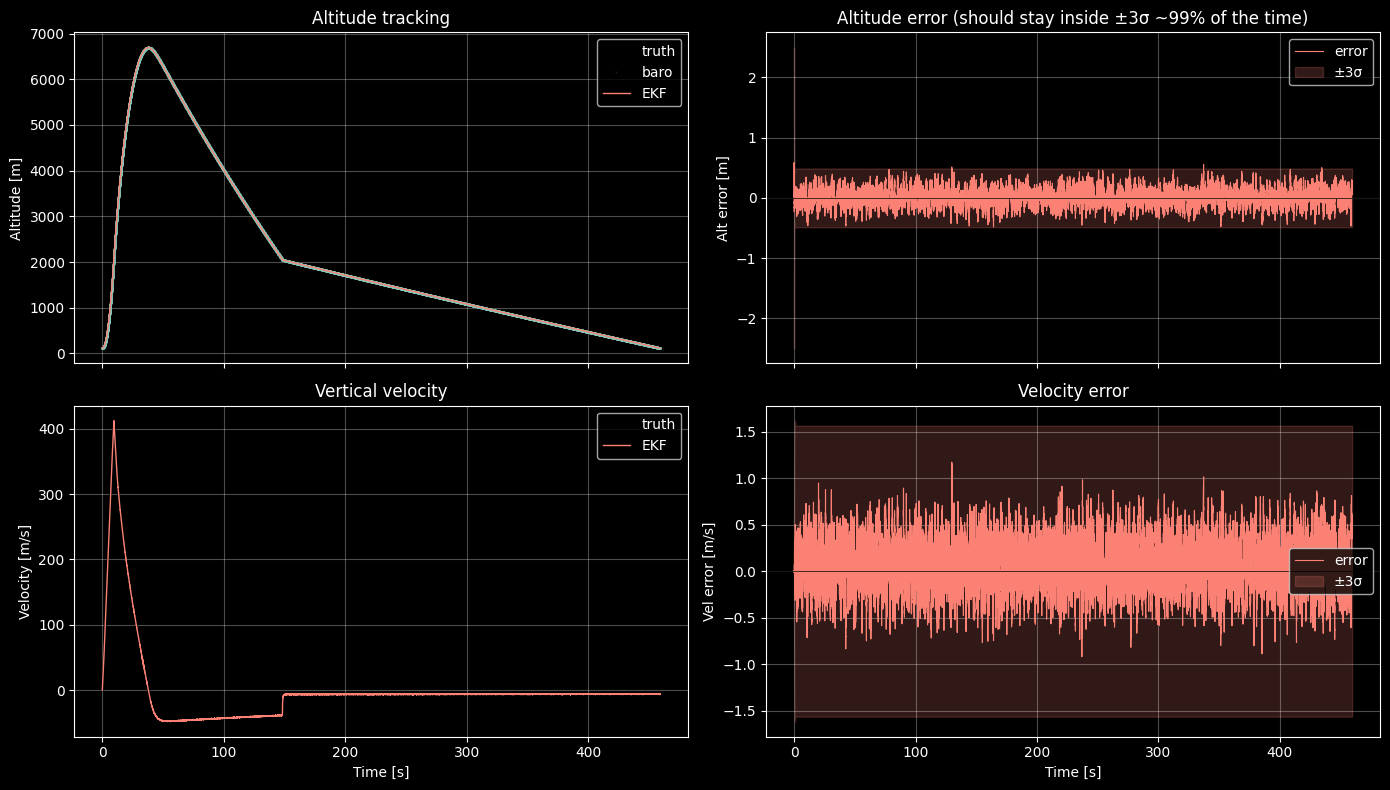

Altitude RMSE: 0.14 m
Velocity RMSE: 0.26 m/s
True apogee:  6693.51 m at t=37.92s
Est apogee:   6693.81 m at t=37.99s
Apogee error: +0.30 m, +0.08 s


In [7]:
est_alt = log['x'][:, 0]
est_vel = log['x'][:, 1]
true_alt = gt['z'].values
true_vel = gt['vz'].values

sigma_alt = np.sqrt(log['P'][:, 0, 0])
sigma_vel = np.sqrt(log['P'][:, 1, 1])

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# Altitude
ax = axes[0, 0]
ax.plot(t, true_alt, 'k-', lw=1.5, label='truth')
ax.plot(t, baro_alt_meas, 'C0.', ms=1, alpha=0.15, label='baro')
ax.plot(t, est_alt, 'C3-', lw=1, label='EKF')
ax.set_ylabel('Altitude [m]'); ax.legend(loc='upper right'); ax.grid(alpha=0.3)
ax.set_title('Altitude tracking')

# Altitude error + 3σ envelope
ax = axes[0, 1]
err_alt = est_alt - true_alt
ax.plot(t, err_alt, 'C3-', lw=0.8, label='error')
ax.fill_between(t, -3*sigma_alt, 3*sigma_alt, alpha=0.2, color='C3', label='±3σ')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Alt error [m]'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Altitude error (should stay inside ±3σ ~99% of the time)')

# Velocity
ax = axes[1, 0]
ax.plot(t, true_vel, 'k-', lw=1.5, label='truth')
ax.plot(t, est_vel, 'C3-', lw=1, label='EKF')
ax.set_ylabel('Velocity [m/s]'); ax.set_xlabel('Time [s]')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Vertical velocity')

# Velocity error + 3σ envelope
ax = axes[1, 1]
err_vel = est_vel - true_vel
ax.plot(t, err_vel, 'C3-', lw=0.8, label='error')
ax.fill_between(t, -3*sigma_vel, 3*sigma_vel, alpha=0.2, color='C3', label='±3σ')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Vel error [m/s]'); ax.set_xlabel('Time [s]')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Velocity error')

plt.tight_layout(); plt.show()

print(f'Altitude RMSE: {np.sqrt(np.mean(err_alt**2)):.2f} m')
print(f'Velocity RMSE: {np.sqrt(np.mean(err_vel**2)):.2f} m/s')

# Apogee check
true_apogee_t = t[np.argmax(true_alt)]
true_apogee_h = true_alt.max()
est_apogee_t = t[np.argmax(est_alt)]
est_apogee_h = est_alt.max()
print(f'True apogee:  {true_apogee_h:7.2f} m at t={true_apogee_t:.2f}s')
print(f'Est apogee:   {est_apogee_h:7.2f} m at t={est_apogee_t:.2f}s')
print(f'Apogee error: {est_apogee_h - true_apogee_h:+.2f} m, {est_apogee_t - true_apogee_t:+.2f} s')

### 5.2 Innovations (are residuals zero-mean white noise?)

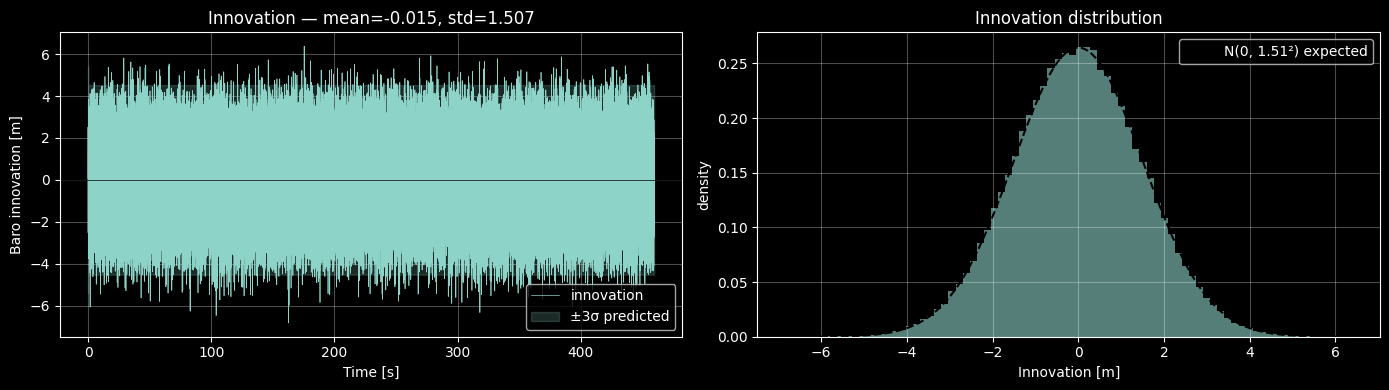

Interpretation:
  mean ≈ 0:        unbiased ✓ (nonzero mean → model bias)
  std ≈ predicted: consistent ✓ (std > predicted → Q or R too small)


In [8]:
mask = ~np.isnan(log['innov'])
innov = log['innov'][mask]
innov_std = np.sqrt(log['innov_cov'][mask])
t_innov = t[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(t_innov, innov, 'C0-', lw=0.5, label='innovation')
ax.fill_between(t_innov, -3*innov_std, 3*innov_std, alpha=0.2, color='C0', label='±3σ predicted')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time [s]'); ax.set_ylabel('Baro innovation [m]')
ax.set_title(f'Innovation — mean={innov.mean():.3f}, std={innov.std():.3f}')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(innov, bins=80, density=True, alpha=0.6, color='C0')
# Overlay expected Gaussian
xs = np.linspace(innov.min(), innov.max(), 200)
expected_std = np.sqrt(np.nanmean(log['innov_cov']))
ax.plot(xs, np.exp(-xs**2/(2*expected_std**2))/(expected_std*np.sqrt(2*np.pi)),
        'k--', label=f'N(0, {expected_std:.2f}²) expected')
ax.set_xlabel('Innovation [m]'); ax.set_ylabel('density')
ax.set_title('Innovation distribution'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('Interpretation:')
print('  mean ≈ 0:        unbiased ✓ (nonzero mean → model bias)')
print('  std ≈ predicted: consistent ✓ (std > predicted → Q or R too small)')

### 5.3 NIS consistency test (chi-squared)

For scalar baro updates, NIS should be χ²(1)-distributed. Mean should be ≈1. Outside the 95% band = filter is inconsistent.

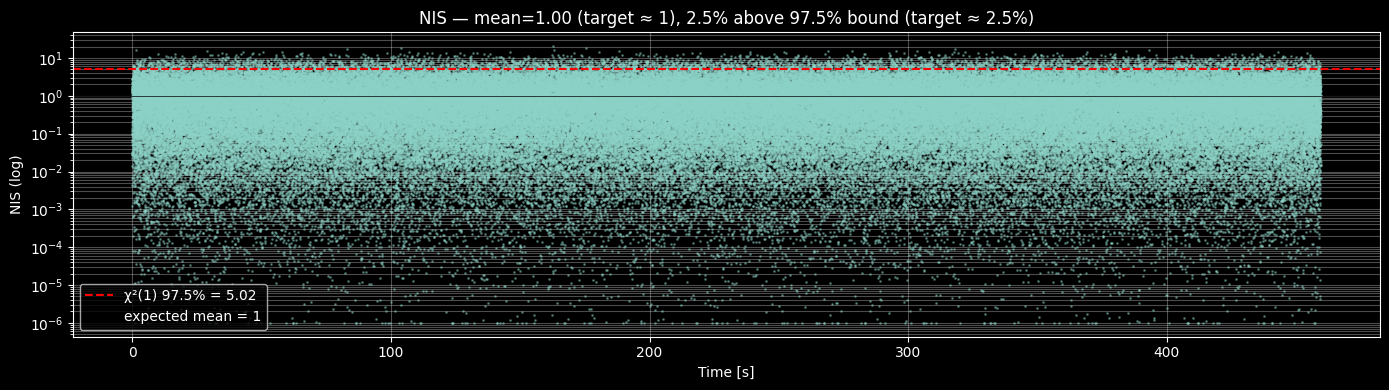

Interpretation:
  mean NIS > 1:  overconfident (increase Q or R)
  mean NIS < 1:  underconfident (decrease Q or R)
  spikes in specific phases: need adaptive R / outlier rejection there


In [9]:
nis = log['nis'][mask]

# 95% confidence bounds for chi2(1)
nis_lo = chi2.ppf(0.025, df=1)   # ~0.001
nis_hi = chi2.ppf(0.975, df=1)   # ~5.02

fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(t_innov, np.clip(nis, 1e-6, None), 'C0.', ms=2, alpha=0.4)
ax.axhline(nis_hi, color='r', ls='--', label=f'χ²(1) 97.5% = {nis_hi:.2f}')
ax.axhline(1.0, color='k', ls='-', lw=0.5, label='expected mean = 1')
ax.set_xlabel('Time [s]'); ax.set_ylabel('NIS (log)')
ax.set_title(f'NIS — mean={nis.mean():.2f} (target ≈ 1), '
             f'{(nis > nis_hi).mean()*100:.1f}% above 97.5% bound (target ≈ 2.5%)')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('Interpretation:')
print('  mean NIS > 1:  overconfident (increase Q or R)')
print('  mean NIS < 1:  underconfident (decrease Q or R)')
print('  spikes in specific phases: need adaptive R / outlier rejection there')

### 5.4 Covariance evolution

Sigmas should grow during prediction, shrink on updates. Monotonic growth or collapse to zero = bug.

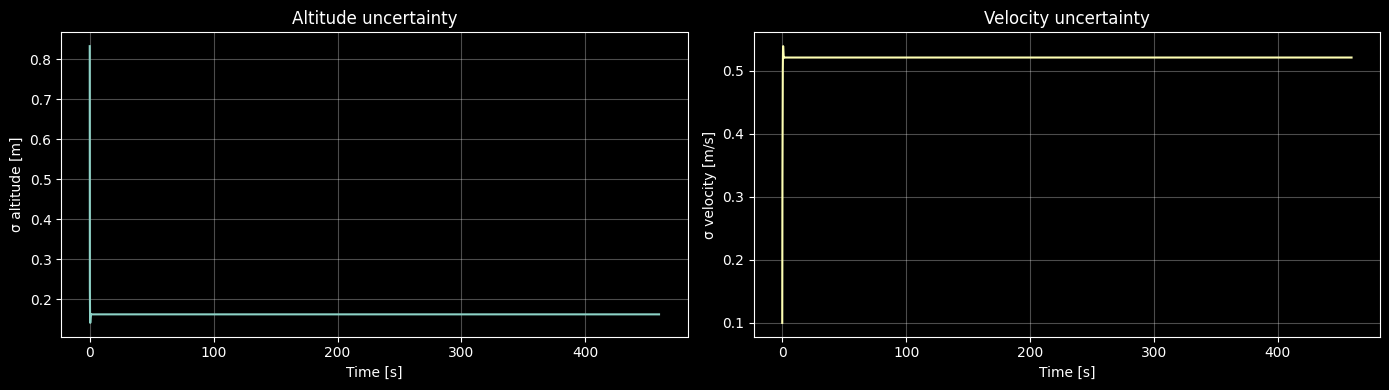

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
axes[0].plot(t, sigma_alt, 'C0-')
axes[0].set_ylabel('σ altitude [m]'); axes[0].set_xlabel('Time [s]')
axes[0].set_title('Altitude uncertainty'); axes[0].grid(alpha=0.3)

axes[1].plot(t, sigma_vel, 'C1-')
axes[1].set_ylabel('σ velocity [m/s]'); axes[1].set_xlabel('Time [s]')
axes[1].set_title('Velocity uncertainty'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 5.5 Phase-segmented error check

Rocket flight has distinct phases with different noise characteristics. Break errors down by phase to find where your filter struggles.

In [11]:
# Simple phase detection from ground truth
apogee_idx = np.argmax(true_alt)
burnout_idx = np.argmax(true_vel)  # velocity peaks at burnout

phases = {
    'pad/boost':  slice(0, burnout_idx),
    'coast':      slice(burnout_idx, apogee_idx),
    'descent':    slice(apogee_idx, len(t)),
}

print(f'{"phase":<12} {"duration":>10} {"alt RMSE":>12} {"vel RMSE":>12}  {"mean NIS":>10}')
print('-' * 60)
for name, sl in phases.items():
    dt_phase = t[sl][-1] - t[sl][0]
    alt_rmse = np.sqrt(np.mean(err_alt[sl]**2))
    vel_rmse = np.sqrt(np.mean(err_vel[sl]**2))
    nis_phase = log['nis'][sl]
    mean_nis = np.nanmean(nis_phase)
    print(f'{name:<12} {dt_phase:>8.1f} s {alt_rmse:>10.2f} m {vel_rmse:>9.2f} m/s {mean_nis:>10.2f}')

phase          duration     alt RMSE     vel RMSE    mean NIS
------------------------------------------------------------
pad/boost         9.6 s       0.11 m      0.20 m/s       1.01
coast            28.3 s       0.15 m      0.27 m/s       1.00
descent         421.5 s       0.14 m      0.26 m/s       1.00


## 6. Quick pass/fail summary

Eyeball these to decide if your filter is basically working before you go deeper.

In [12]:
checks = []
checks.append(('Altitude RMSE < 5 m',      np.sqrt(np.mean(err_alt**2)) < 5.0))
checks.append(('Velocity RMSE < 5 m/s',    np.sqrt(np.mean(err_vel**2)) < 5.0))
checks.append(('Apogee alt error < 10 m',  abs(est_apogee_h - true_apogee_h) < 10.0))
checks.append(('Apogee time error < 0.5s', abs(est_apogee_t - true_apogee_t) < 0.5))
checks.append(('Innovation mean < 0.5 m',  abs(innov.mean()) < 0.5))
checks.append(('Mean NIS in [0.3, 3.0]',   0.3 < nis.mean() < 3.0))
checks.append(('Error within ±3σ >95%',   (np.abs(err_alt) < 3*sigma_alt).mean() > 0.95))

print('=' * 40)
for name, ok in checks:
    print(f'  [{"✓" if ok else "✗"}] {name}')
print('=' * 40)
print(f'  {sum(ok for _, ok in checks)}/{len(checks)} checks passed')

  [✓] Altitude RMSE < 5 m
  [✓] Velocity RMSE < 5 m/s
  [✓] Apogee alt error < 10 m
  [✓] Apogee time error < 0.5s
  [✓] Innovation mean < 0.5 m
  [✓] Mean NIS in [0.3, 3.0]
  [✓] Error within ±3σ >95%
  7/7 checks passed
